Data Sample:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Decision Tree Accuracy: 0.9853658536585366


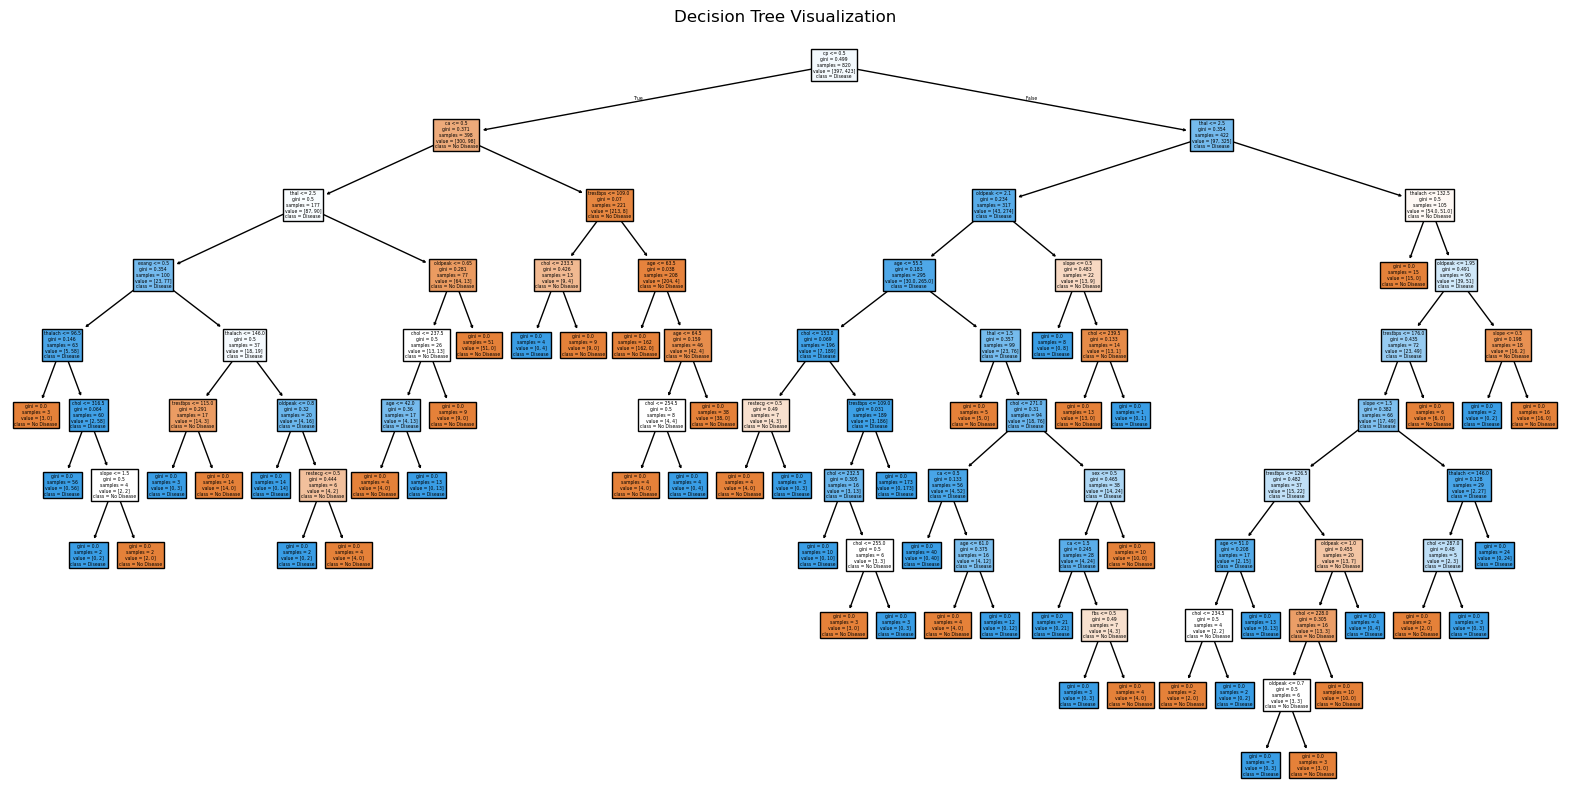

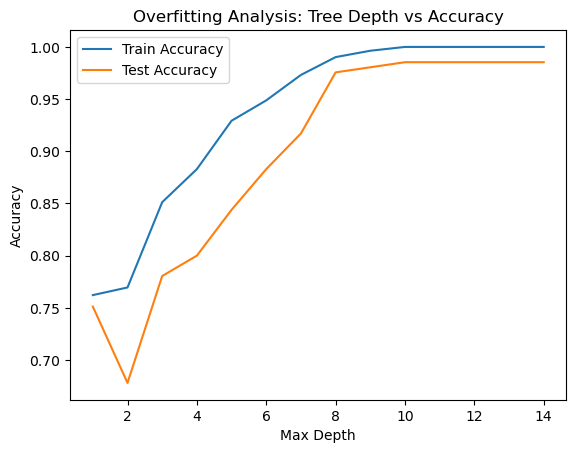


Random Forest Accuracy: 0.9853658536585366


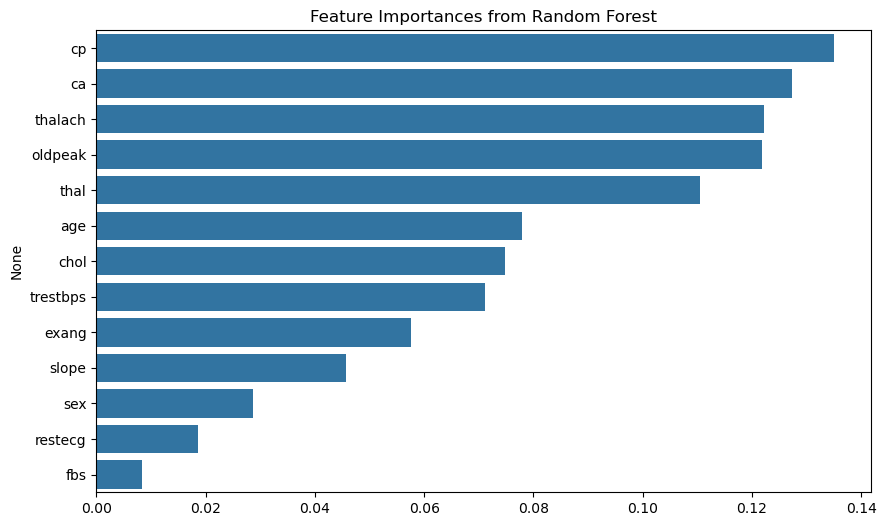


Cross-Validation Accuracy:
Decision Tree: 100.00%
Random Forest: 99.71%

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('heart.csv')  # Assuming it's in the same folder
print("Data Sample:")
print(data.head())

# Features and target
X = data.drop('target', axis=1)
y = data['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Train a Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Predict and check accuracy
y_pred_tree = dtree.predict(X_test)
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

# 6. Visualize the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(dtree, filled=True, feature_names=X.columns, class_names=["No Disease", "Disease"])
plt.title("Decision Tree Visualization")
plt.show()

# 2. Analyze overfitting and control tree depth
train_scores = []
test_scores = []
depth_range = range(1, 15)

for depth in depth_range:
    temp_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_tree.fit(X_train, y_train)
    train_scores.append(temp_tree.score(X_train, y_train))
    test_scores.append(temp_tree.score(X_test, y_test))

plt.figure()
plt.plot(depth_range, train_scores, label="Train Accuracy")
plt.plot(depth_range, test_scores, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Tree Depth vs Accuracy")
plt.legend()
plt.show()

# 3. Train a Random Forest and compare accuracy
rforest = RandomForestClassifier(n_estimators=100, random_state=42)
rforest.fit(X_train, y_train)
y_pred_rf = rforest.predict(X_test)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# 4. Interpret Feature Importances
importances = rforest.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Feature Importances from Random Forest")
plt.show()

# 5. Evaluate using cross-validation
cv_scores_dt = cross_val_score(dtree, X, y, cv=5)
cv_scores_rf = cross_val_score(rforest, X, y, cv=5)
print("\nCross-Validation Accuracy:")
print("Decision Tree: {:.2f}%".format(cv_scores_dt.mean() * 100))
print("Random Forest: {:.2f}%".format(cv_scores_rf.mean() * 100))
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))
